# MLP Classifier Demo
This notebook demonstrates:
1. Training a sklearn MLPClassifier
2. Saving the model to JSON
3. Loading and using the custom MLPClassifier class

## 1. Import Libraries and Load Data

In [18]:
import numpy as np
import pandas as pd
import json
from sklearn.neural_network import MLPClassifier as SklearnMLP
from sklearn.metrics import accuracy_score, classification_report
import sys
sys.path.append('..')
import pickle

from helpers.save_model_params import extract_mlp_to_dict
from helpers.tfidf_vectorizer import TfidfVectorizer
from models.neural_networks.mlp_classifier import MLPClassifier

import matplotlib.pyplot as plt

import warnings
warnings.filterwarnings('ignore', message='Got `batch_size` less than 1 or larger than sample size')


In [19]:
# Configure data paths
train_data_path = 'data/train_data_raw.csv'
val_data_path = 'data/validation_data_raw.csv'
test_data_path = 'data/test_data_raw.csv'
random_seed = 42

print("Data paths configured")
print(f"Train: {train_data_path}")
print(f"Validation: {val_data_path}")
print(f"Test: {test_data_path}")

Data paths configured
Train: data/train_data_raw.csv
Validation: data/validation_data_raw.csv
Test: data/test_data_raw.csv


## 2. Prepare Data

In [20]:
# Initialize TfidfVectorizer and build vocabulary
dataloader = TfidfVectorizer(seed=random_seed, truncate_length=4)
dataloader.build_vocab(train_data_path, verbose=True)

print(f"\nVocabulary size: {dataloader.get_vocab_size()}")

Building vocabulary from data/train_data_raw.csv...
Reading data from data/train_data_raw.csv...
Cleaning data...
Computing feature scaling parameters...

Vocabulary size: 1634


In [21]:
# Generate TF-IDF features for train and test sets
normalize = True
standardize = False
verbose = True

X_train, y_train = dataloader.generate_Xt(train_data_path, normalize=normalize, verbose=verbose, standardize=standardize)
X_test, y_test = dataloader.generate_Xt(test_data_path, normalize=normalize, verbose=verbose, standardize=standardize)
X_val, y_val = dataloader.generate_Xt(val_data_path, normalize=normalize, verbose=verbose, standardize=standardize)
print(f"\nX_train shape: {X_train.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_test shape: {y_test.shape}")
print(f"X_val shape: {X_val.shape}")
print(f"y_val shape: {y_val.shape}")
print(f"Number of classes: {len(np.unique(y_train))}")

Generating features and targets from data/train_data_raw.csv...
Reading data from data/train_data_raw.csv...
Cleaning data...
Generating features and targets from data/test_data_raw.csv...
Reading data from data/test_data_raw.csv...
Cleaning data...
Generating features and targets from data/validation_data_raw.csv...
Reading data from data/validation_data_raw.csv...
Cleaning data...

X_train shape: (648, 1654)
y_train shape: (648,)
X_test shape: (27, 1654)
y_test shape: (27,)
X_val shape: (150, 1654)
y_val shape: (150,)
Number of classes: 3


## 3. Train sklearn MLPClassifier

In [22]:
def tune_mlp_hyperparameters(X_train, y_train, X_val, y_val, random_seed=42):
    """
    Tune MLP hyperparameters using grid search on validation set.
    
    Parameters:
    -----------
    X_train : array-like
        Training features
    y_train : array-like
        Training labels
    X_val : array-like
        Validation features
    y_val : array-like
        Validation labels
    random_seed : int
        Random seed for reproducibility
        
    Returns:
    --------
    dict : Dictionary containing best parameters, best score, and all results
    """
    from sklearn.model_selection import ParameterGrid
    from datetime import datetime
    
    # Define hyperparameter grid
    param_grid = {
        'hidden_layer_sizes': [
            (128,),
            (256,),
            (128, 64),
            (256, 128),
        ],
        'alpha': [0.0001, 0.001, 0.01],
        'learning_rate_init': [0.001, 0.01],
        'batch_size': [len(X_train)],
        'max_iter': [500]
    }

    # param_grid = {
    #     'hidden_layer_sizes': [
    #         (64,),
    #     ],
    #     'alpha': [0.01],
    #     'learning_rate_init': [0.01],
    #     'batch_size': [len(X_train)],
    #     'max_iter': [500]
    # }
    
    # Create parameter combinations
    grid = list(ParameterGrid(param_grid))
    total_combinations = len(grid)
    
    print(f"Starting hyperparameter tuning...")
    print(f"Total combinations to test: {total_combinations}")
    print(f"Training samples: {len(X_train)}, Validation samples: {len(X_val)}")
    print("=" * 80)
    
    # Track results
    results = []
    best_score = 0
    best_params = None
    best_model = None
    
    start_time = datetime.now()
    
    # Iterate through all parameter combinations
    for idx, params in enumerate(grid, 1):
        try:
            # average over 5 runs
            avg_val_accuracy = 0
            avg_train_accuracy = 0
            runs = 1

            for run in range(runs):
                # Create model with current parameters
                mlp = SklearnMLP(
                    hidden_layer_sizes=params['hidden_layer_sizes'],
                    activation='relu',
                    solver='adam',
                    alpha=params['alpha'],
                    batch_size=params['batch_size'],
                    learning_rate='adaptive',
                    learning_rate_init=params['learning_rate_init'],
                    max_iter=params['max_iter'],
                    shuffle=True,
                    random_state=random_seed,
                    verbose=False,
                    early_stopping=True,
                    validation_fraction=0.15,
                    n_iter_no_change=20,
                    epsilon=1e-8
                )
                
                # Train model
                mlp.fit(X_train, y_train)
                
                # Evaluate on validation set
                val_pred = mlp.predict(X_val)
                val_accuracy = accuracy_score(y_val, val_pred)
                train_pred = mlp.predict(X_train)
                train_accuracy = accuracy_score(y_train, train_pred)
                avg_val_accuracy += val_accuracy
                avg_train_accuracy += train_accuracy
            
            avg_val_accuracy /= runs
            avg_train_accuracy /= runs

            # Store results
            result = {
                'params': params.copy(),
                'val_accuracy': avg_val_accuracy,
                'train_accuracy': avg_train_accuracy,
                'n_iter': mlp.n_iter_,
                'final_loss': mlp.loss_
            }
            results.append(result)
            
            # Update best model if current is better
            if avg_val_accuracy > best_score:
                best_score = avg_val_accuracy
                best_params = params.copy()
                best_model = mlp
                print(f"🎯 New best! Val Acc: {avg_val_accuracy:.4f}")
            
            # Print progress
            if idx % 5 == 0 or idx == total_combinations:
                elapsed = (datetime.now() - start_time).total_seconds()
                avg_time = elapsed / idx
                eta = avg_time * (total_combinations - idx)
                print(f"Progress: {idx}/{total_combinations} | "
                      f"Current Val Acc: {avg_val_accuracy / 5:.4f} | "
                      f"Best Val Acc: {best_score:.4f} | "
                      f"ETA: {eta:.0f}s")
        
        except Exception as e:
            print(f"Error with params {params}: {str(e)}")
            continue
    
    total_time = (datetime.now() - start_time).total_seconds()
    
    print("\n" + "=" * 80)
    print(f"Tuning complete! Total time: {total_time:.1f}s")
    print(f"\nBest validation accuracy: {best_score:.4f}")
    print(f"Best parameters:")
    for key, value in best_params.items():
        print(f"  {key}: {value}")
    
    # Sort results by validation accuracy
    results_sorted = sorted(results, key=lambda x: x['val_accuracy'], reverse=True)
    
    return {
        'best_params': best_params,
        'best_score': best_score,
        'best_model': best_model,
        'all_results': results_sorted,
        'total_time': total_time
    }

print("Hyperparameter tuning function defined!")

Hyperparameter tuning function defined!


### Run Hyperparameter Tuning

In [23]:
# Run hyperparameter tuning
tuning_results = tune_mlp_hyperparameters(X_train, y_train, X_val, y_val, random_seed=random_seed)

# Store best model and parameters
best_mlp = tuning_results['best_model']
best_params = tuning_results['best_params']

Starting hyperparameter tuning...
Total combinations to test: 24
Training samples: 648, Validation samples: 150
🎯 New best! Val Acc: 0.6933
Progress: 5/24 | Current Val Acc: 0.1360 | Best Val Acc: 0.6933 | ETA: 9s
Progress: 10/24 | Current Val Acc: 0.1387 | Best Val Acc: 0.6933 | ETA: 10s
Progress: 15/24 | Current Val Acc: 0.1320 | Best Val Acc: 0.6933 | ETA: 9s
Progress: 20/24 | Current Val Acc: 0.1347 | Best Val Acc: 0.6933 | ETA: 4s
🎯 New best! Val Acc: 0.7000
Progress: 24/24 | Current Val Acc: 0.1400 | Best Val Acc: 0.7000 | ETA: 0s

Tuning complete! Total time: 26.4s

Best validation accuracy: 0.7000
Best parameters:
  alpha: 0.01
  batch_size: 648
  hidden_layer_sizes: (256, 128)
  learning_rate_init: 0.01
  max_iter: 500


### Analyze Tuning Results

In [24]:
# Display top 10 configurations
print("Top 10 Configurations by Validation Accuracy:")
print("=" * 100)

top_results_df = pd.DataFrame([
    {
        'Rank': i+1,
        'Val Acc': r['val_accuracy'],
        'Train Acc': r['train_accuracy'],
        'Layers': str(r['params']['hidden_layer_sizes']),
        'Alpha': r['params']['alpha'],
        'LR': r['params']['learning_rate_init'],
        'Batch': r['params']['batch_size'],
        'Iters': r['n_iter'],
        'Loss': r['final_loss']
    }
    for i, r in enumerate(tuning_results['all_results'][:10])
])

pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)
pd.set_option('display.max_colwidth', None)
print(top_results_df.to_string(index=False))

# Summary statistics
print(f"\n{'=' * 100}")
print(f"Summary Statistics:")
print(f"  Best validation accuracy: {tuning_results['best_score']:.4f}")
print(f"  Average validation accuracy: {np.mean([r['val_accuracy'] for r in tuning_results['all_results']]):.4f}")
print(f"  Std validation accuracy: {np.std([r['val_accuracy'] for r in tuning_results['all_results']]):.4f}")
print(f"  Total tuning time: {tuning_results['total_time']:.1f}s")

Top 10 Configurations by Validation Accuracy:
 Rank  Val Acc  Train Acc     Layers  Alpha    LR  Batch  Iters     Loss
    1 0.700000   0.842593 (256, 128) 0.0100 0.010    648     27 0.033456
    2 0.693333   0.782407     (128,) 0.0001 0.001    648     49 0.440703
    3 0.693333   0.782407     (128,) 0.0010 0.001    648     49 0.440776
    4 0.693333   0.777778     (128,) 0.0010 0.010    648     27 0.026819
    5 0.693333   0.770062  (128, 64) 0.0010 0.001    648     41 0.333838
    6 0.693333   0.777778     (128,) 0.0100 0.010    648     27 0.051395
    7 0.686667   0.777778     (128,) 0.0001 0.010    648     27 0.023909
    8 0.686667   0.779321     (128,) 0.0100 0.001    648     48 0.454771
    9 0.680000   0.765432  (128, 64) 0.0001 0.001    648     40 0.353070
   10 0.680000   0.766975  (128, 64) 0.0100 0.001    648     40 0.360177

Summary Statistics:
  Best validation accuracy: 0.7000
  Average validation accuracy: 0.6608
  Std validation accuracy: 0.0340
  Total tuning time: 26

C:\Users\david\AppData\Local\Temp\ipykernel_8412\1210464050.py:68: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axes[1, 1].legend()


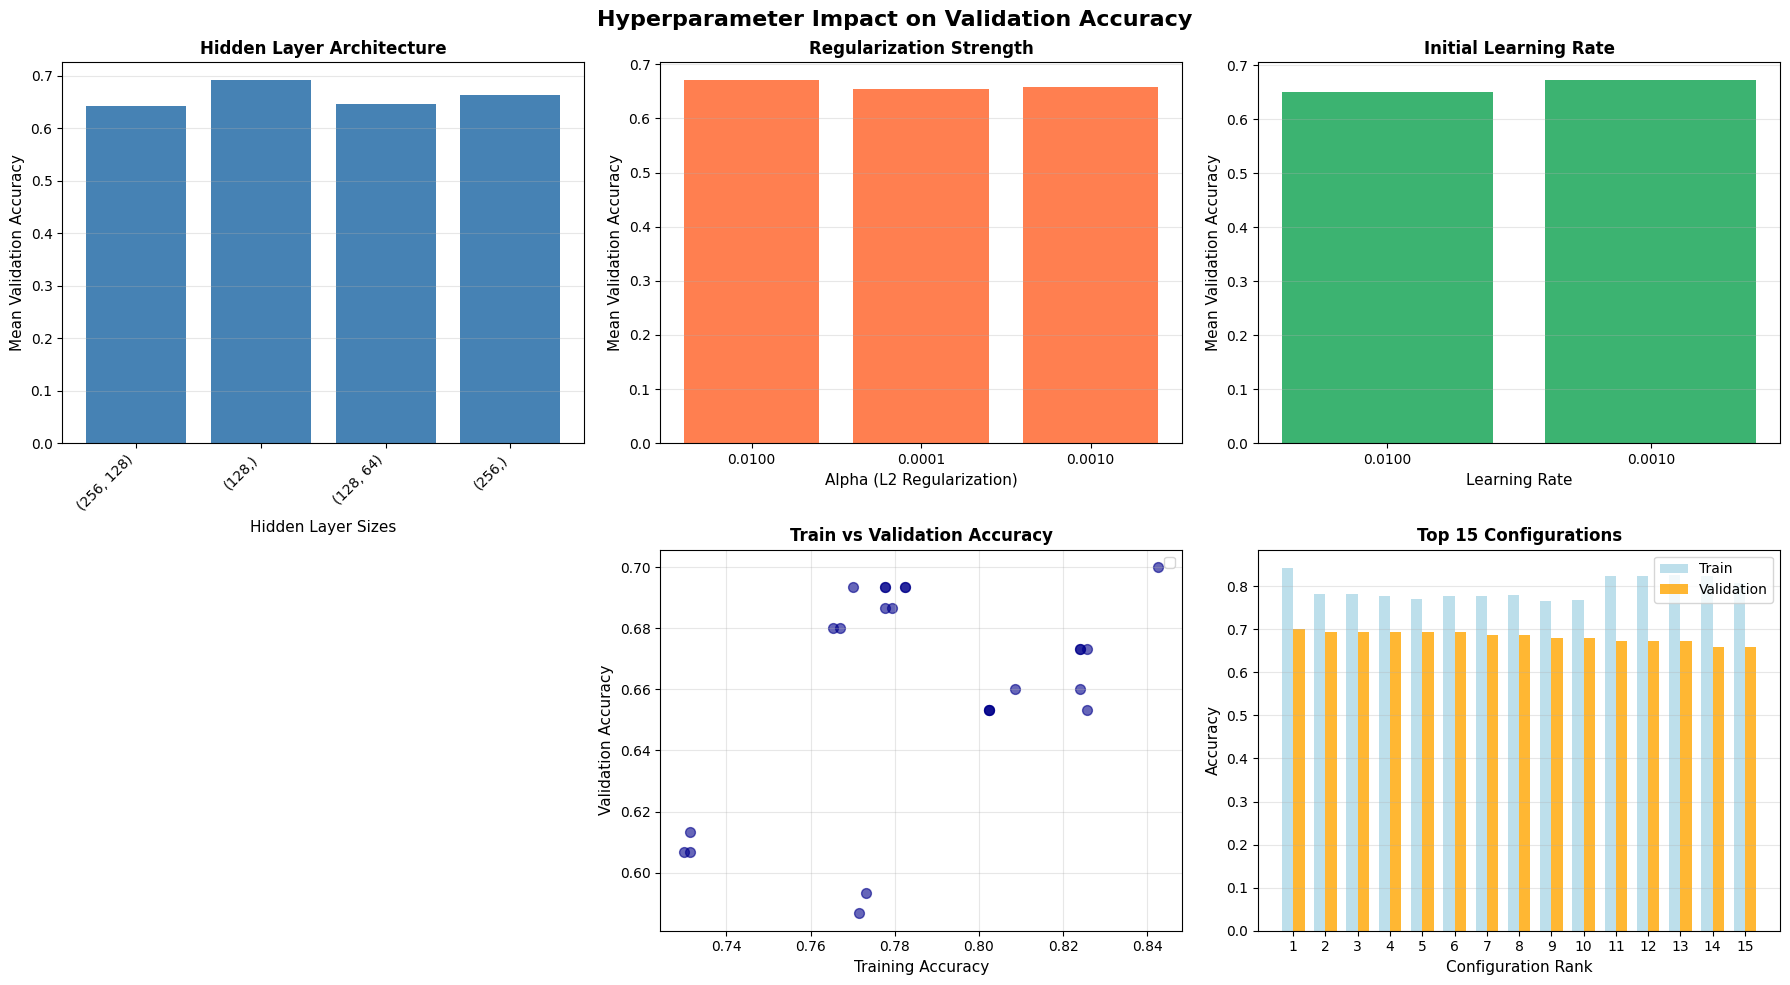


Best configuration achieves 0.7000 validation accuracy


In [25]:
# Visualize hyperparameter impact
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('Hyperparameter Impact on Validation Accuracy', fontsize=16, fontweight='bold')

results_list = tuning_results['all_results']

# 1. Hidden layer sizes
layer_sizes = {}
for r in results_list:
    key = str(r['params']['hidden_layer_sizes'])
    if key not in layer_sizes:
        layer_sizes[key] = []
    layer_sizes[key].append(r['val_accuracy'])

layer_means = {k: np.mean(v) for k, v in layer_sizes.items()}
axes[0, 0].bar(range(len(layer_means)), list(layer_means.values()), color='steelblue')
axes[0, 0].set_xticks(range(len(layer_means)))
axes[0, 0].set_xticklabels(list(layer_means.keys()), rotation=45, ha='right')
axes[0, 0].set_xlabel('Hidden Layer Sizes', fontsize=11)
axes[0, 0].set_ylabel('Mean Validation Accuracy', fontsize=11)
axes[0, 0].set_title('Hidden Layer Architecture', fontsize=12, fontweight='bold')
axes[0, 0].grid(axis='y', alpha=0.3)

# 2. Alpha (L2 regularization)
alpha_values = {}
for r in results_list:
    key = r['params']['alpha']
    if key not in alpha_values:
        alpha_values[key] = []
    alpha_values[key].append(r['val_accuracy'])

alpha_means = {k: np.mean(v) for k, v in alpha_values.items()}
axes[0, 1].bar(range(len(alpha_means)), list(alpha_means.values()), color='coral')
axes[0, 1].set_xticks(range(len(alpha_means)))
axes[0, 1].set_xticklabels([f"{k:.4f}" for k in alpha_means.keys()])
axes[0, 1].set_xlabel('Alpha (L2 Regularization)', fontsize=11)
axes[0, 1].set_ylabel('Mean Validation Accuracy', fontsize=11)
axes[0, 1].set_title('Regularization Strength', fontsize=12, fontweight='bold')
axes[0, 1].grid(axis='y', alpha=0.3)

# 3. Learning rate
lr_values = {}
for r in results_list:
    key = r['params']['learning_rate_init']
    if key not in lr_values:
        lr_values[key] = []
    lr_values[key].append(r['val_accuracy'])

lr_means = {k: np.mean(v) for k, v in lr_values.items()}
axes[0, 2].bar(range(len(lr_means)), list(lr_means.values()), color='mediumseagreen')
axes[0, 2].set_xticks(range(len(lr_means)))
axes[0, 2].set_xticklabels([f"{k:.4f}" for k in lr_means.keys()])
axes[0, 2].set_xlabel('Learning Rate', fontsize=11)
axes[0, 2].set_ylabel('Mean Validation Accuracy', fontsize=11)
axes[0, 2].set_title('Initial Learning Rate', fontsize=12, fontweight='bold')
axes[0, 2].grid(axis='y', alpha=0.3)

# 4. Batch size (hidden)
axes[1, 0].axis('off')

# 5. Train vs Val accuracy (overfitting check)
train_accs = [r['train_accuracy'] for r in results_list]
val_accs = [r['val_accuracy'] for r in results_list]
axes[1, 1].scatter(train_accs, val_accs, alpha=0.6, s=50, color='darkblue')
axes[1, 1].set_xlabel('Training Accuracy', fontsize=11)
axes[1, 1].set_ylabel('Validation Accuracy', fontsize=11)
axes[1, 1].set_title('Train vs Validation Accuracy', fontsize=12, fontweight='bold')
axes[1, 1].legend()
axes[1, 1].grid(alpha=0.3)

# 6. Top 15 configurations comparison
top_n = 15
top_configs = results_list[:top_n]
indices = range(1, len(top_configs) + 1)
train_top = [r['train_accuracy'] for r in top_configs]
val_top = [r['val_accuracy'] for r in top_configs]

x = np.arange(len(indices))
width = 0.35

axes[1, 2].bar(x - width/2, train_top, width, label='Train', color='lightblue', alpha=0.8)
axes[1, 2].bar(x + width/2, val_top, width, label='Validation', color='orange', alpha=0.8)
axes[1, 2].set_xlabel('Configuration Rank', fontsize=11)
axes[1, 2].set_ylabel('Accuracy', fontsize=11)
axes[1, 2].set_title(f'Top {top_n} Configurations', fontsize=12, fontweight='bold')
axes[1, 2].set_xticks(x)
axes[1, 2].set_xticklabels(indices)
axes[1, 2].legend()
axes[1, 2].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\nBest configuration achieves {tuning_results['best_score']:.4f} validation accuracy")

### Evaluate Best Model

In [26]:
# Evaluate best model on all sets
best_train_pred = best_mlp.predict(X_train)
best_val_pred = best_mlp.predict(X_val)
# best_test_pred = best_mlp.predict(X_test)

print("=" * 80)
print("BEST MODEL PERFORMANCE")
print("=" * 80)
print(f"\nBest Hyperparameters:")
for key, value in best_params.items():
    print(f"  {key}: {value}")

print(f"\n{'Accuracy Scores:'}")
print(f"  Training Accuracy:   {accuracy_score(y_train, best_train_pred):.4f}")
print(f"  Validation Accuracy: {accuracy_score(y_val, best_val_pred):.4f}")
# print(f"  Test Accuracy:       {accuracy_score(y_test, best_test_pred):.4f}")

print(f"\n{'Training Details:'}")
print(f"  Number of iterations: {best_mlp.n_iter_}")
print(f"  Final loss: {best_mlp.loss_:.4f}")

print(f"\n{'Classification Report (Validation Set):'}")
print(classification_report(y_val, best_val_pred, digits=4))

BEST MODEL PERFORMANCE

Best Hyperparameters:
  alpha: 0.01
  batch_size: 648
  hidden_layer_sizes: (256, 128)
  learning_rate_init: 0.01
  max_iter: 500

Accuracy Scores:
  Training Accuracy:   0.8426
  Validation Accuracy: 0.7000

Training Details:
  Number of iterations: 27
  Final loss: 0.0335

Classification Report (Validation Set):
              precision    recall  f1-score   support

           0     0.7667    0.9200    0.8364        50
           1     0.6094    0.7800    0.6842        50
           2     0.7692    0.4000    0.5263        50

    accuracy                         0.7000       150
   macro avg     0.7151    0.7000    0.6823       150
weighted avg     0.7151    0.7000    0.6823       150



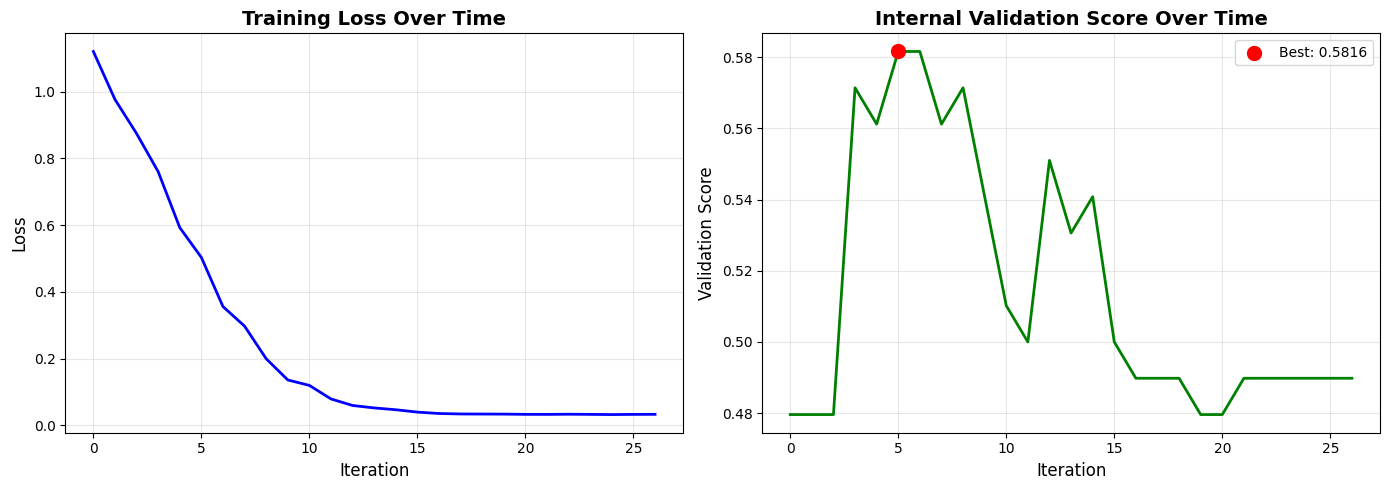


Training Statistics:
Final training loss: 0.033456
Total iterations: 27
Best internal validation score: 0.5816
Final internal validation score: 0.4898

Note: Internal validation uses 10% of training data for early stopping


In [27]:
# Plot training progress
import matplotlib.pyplot as plt

sklearn_mlp = best_mlp

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Plot loss curve
ax1.plot(sklearn_mlp.loss_curve_, linewidth=2, color='blue')
ax1.set_xlabel('Iteration', fontsize=12)
ax1.set_ylabel('Loss', fontsize=12)
ax1.set_title('Training Loss Over Time', fontsize=14, fontweight='bold')
ax1.grid(True, alpha=0.3)

# Plot validation scores
if hasattr(sklearn_mlp, 'validation_scores_') and len(sklearn_mlp.validation_scores_) > 0:
    ax2.plot(sklearn_mlp.validation_scores_, linewidth=2, color='green')
    ax2.set_xlabel('Iteration', fontsize=12)
    ax2.set_ylabel('Validation Score', fontsize=12)
    ax2.set_title('Internal Validation Score Over Time', fontsize=14, fontweight='bold')
    ax2.grid(True, alpha=0.3)
    
    # Mark the best validation score
    best_idx = np.argmax(sklearn_mlp.validation_scores_)
    best_score = sklearn_mlp.validation_scores_[best_idx]
    ax2.scatter([best_idx], [best_score], color='red', s=100, zorder=5, label=f'Best: {best_score:.4f}')
    ax2.legend()

plt.tight_layout()
plt.show()

print(f"\nTraining Statistics:")
print(f"Final training loss: {sklearn_mlp.loss_:.6f}")
print(f"Total iterations: {sklearn_mlp.n_iter_}")
if hasattr(sklearn_mlp, 'validation_scores_') and len(sklearn_mlp.validation_scores_) > 0:
    print(f"Best internal validation score: {max(sklearn_mlp.validation_scores_):.4f}")
    print(f"Final internal validation score: {sklearn_mlp.validation_scores_[-1]:.4f}")
print(f"\nNote: Internal validation uses 10% of training data for early stopping")

## 4. Save Model to JSON

In [28]:
# Generate feature names
vocab_size = dataloader.get_vocab_size()
feature_names = [f"{i}" for i in range(vocab_size)]

# Extract model to dictionary
mlp_dict = extract_mlp_to_dict(sklearn_mlp, feature_names=feature_names)

# Save to pickle file
output_path = '../models/fitted_mlp.pkl'
with open(output_path, 'wb') as f:
    pickle.dump(mlp_dict, f)

print(f"Model saved to: {output_path}")
print(f"\nModel metadata:")
for key, value in mlp_dict['metadata'].items():
    if key != 'feature_names':
        print(f"  {key}: {value}")

Model saved to: ../models/fitted_mlp.pkl

Model metadata:
  model_type: MLPClassifier
  n_features: 1654
  n_classes: 3
  n_layers: 4
  n_iter: 27
  loss: 0.03345645406932595
  classes: [0, 1, 2]


## 5. Load Model with Custom MLPClassifier Class

In [29]:
# Load the custom MLP model
custom_mlp = MLPClassifier('../models/fitted_mlp.pkl')

MLP model loaded from: ../models/fitted_mlp.pkl
Architecture: 1654 -> [256, 128] -> 3


In [30]:
# Make predictions with custom model
custom_train_pred = custom_mlp.predict(X_train)
custom_val_pred = custom_mlp.predict(X_val)

print("Custom MLPClassifier Performance:")
print(f"Training Accuracy: {accuracy_score(y_train, custom_train_pred):.4f}")
print(f"Validation Accuracy: {accuracy_score(y_val, custom_val_pred):.4f}")

Custom MLPClassifier Performance:
Training Accuracy: 0.8426
Validation Accuracy: 0.7000


## 6. Compare Predictions

In [31]:
# Verify predictions match
train_match = np.array_equal(best_train_pred, custom_train_pred)
val_match = np.array_equal(best_val_pred, custom_val_pred)

print("Prediction Comparison:")
print(f"Training predictions match: {train_match}")
print(f"Validation predictions match: {val_match}")

if not val_match:
    diff_count = np.sum(best_val_pred != custom_val_pred)
    print(f"Number of different predictions: {diff_count} out of {len(y_test)}")
    print(f"Difference rate: {diff_count / len(y_test) * 100:.2f}%")

Prediction Comparison:
Training predictions match: True
Validation predictions match: True
